### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº3

## Bernardita Aragón

En este trabajo práctico se analizará el comportamiento en frecuencia de señales senoidales mediante la FFT, observando como variaciones en su frecuencia producen desparramo espectral. Además, se verificará la conservación de la potencia mediante la identidad de Parseval y se estudiará el efecto del zero padding sobre la visualización del espectro.

In [1]:
#importo modulos
import numpy as np
import matplotlib.pyplot as plt

#definiciones
N= 1000
fs= 1000
dc=0
ph=0
valores_k0 = [N/4, (N/4) +0.25, (N/4) +0.5]
k0 = np.array(valores_k0)
f0= k0* (fs/N)
P=1
vmax= np.sqrt(2*P)

#defino la funcion
def mi_funcion_sen( vmax, dc, frecuencia, ph, N, fs):
    
    nn= np.arange(0,N) / fs
    xx= dc + vmax*np.sin(2 * np.pi * frecuencia * nn + ph ) 

    return(nn, xx)

#### Desparramo espectral

##### Primero caso $k0 = N/4$

Para estos parámetros, la frecuencia de la senoidal resulta

$f0 = k0 * (fs/N) = 250 Hz$.

Como esta frecuencia coincide exactamente con uno de los bins de la DFT, se espera que la potencia de la señal quede concentrada principalmente en ese punto del espectro.

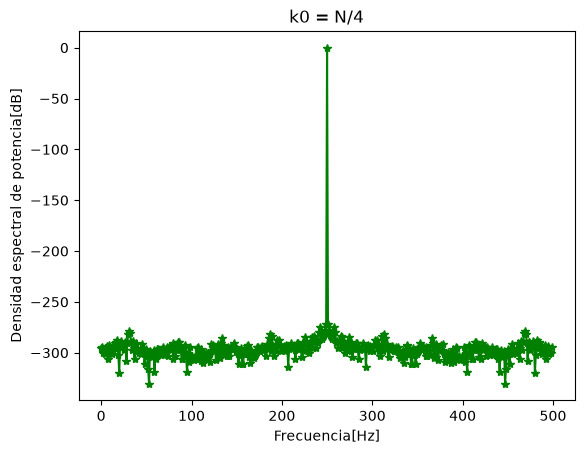

In [2]:
#vector de frecuencias
ff_vec = np.fft.fftfreq(N,1/fs ) 
#funcion
nn, xx0 = mi_funcion_sen( vmax, dc, f0[0], ph, N, fs)
#ff
XX0 = np.fft.fft(xx0) 
XX0_mod = np.abs(XX0[:N//2]) * 2/N
P0 = XX0_mod**2 / 2
P0_db = 10*np.log10(P0)
#grafico
plt.plot(ff_vec[:N//2], P0_db, 'g-*')
plt.title("k0 = N/4")
plt.xlabel("Frecuencia[Hz]")
plt.ylabel("Densidad espectral de potencia[dB]")
plt.show()

En el gráfico se puede ver que se cumple lo esperado para este primer caso: la potencia queda prácticamente concentrada en un único punto del espectro y no se observa desparramo espectral.

Además, el pico alcanza aproximadamente 0 dB, como era de esperar al haber definido una señal de potencia unitaria. Los valores muy pequeños que aparecen en el resto del espectro se deben principalmente a errores numéricos del cálculo de la FFT.

##### Segundo caso $k0 = N/4 + 0.25$

En este caso la frecuencia de la senoidal deja de coincidir exactamente con un bin de la DFT, por lo que se espera observar desparramo espectral.

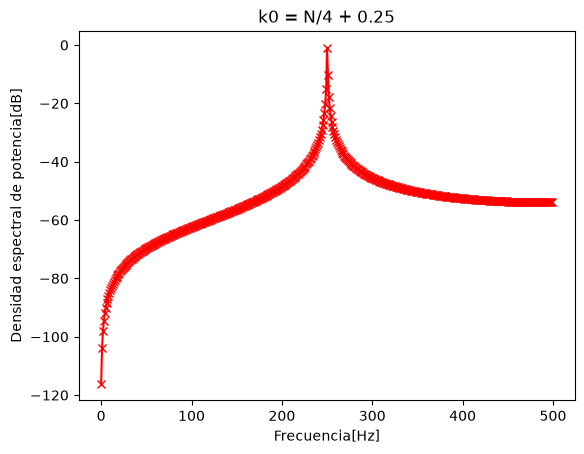

In [3]:
nn, xx1 = mi_funcion_sen( vmax, dc, f0[1], ph, N, fs)
XX1 = np.fft.fft(xx1) 
XX1_mod = np.abs(XX1[:N//2]) * 2/N
P1 = XX1_mod**2 / 2
P1_db = 10*np.log10(P1)
#grafico
plt.plot(ff_vec[:N//2], P1_db,'r-x')
plt.title("k0 = N/4 + 0.25")
plt.xlabel("Frecuencia[Hz]")
plt.ylabel("Densidad espectral de potencia[dB]")
plt.show()

En este segundo caso se observa claramente el desparramo espectral esperado. A diferencia del caso anterior, la potencia ya no queda concentrada en un único bin, sino que se distribuye entre varias frecuencias alrededor del máximo.

También se observa que el pico ya no alcanza los 0 dB, debido a que la frecuencia de la senoidal no coincide exactamente con uno de los bins de la DFT. 

##### Caso $k0 = N/4 + 0.5$

En este caso la frecuencia de la senoidal queda justo entre dos bins consecutivos de la DFT. Por este motivo, se espera observar un desparramo espectral todavía más marcado, ya que la potencia no puede concentrarse en un único bin.

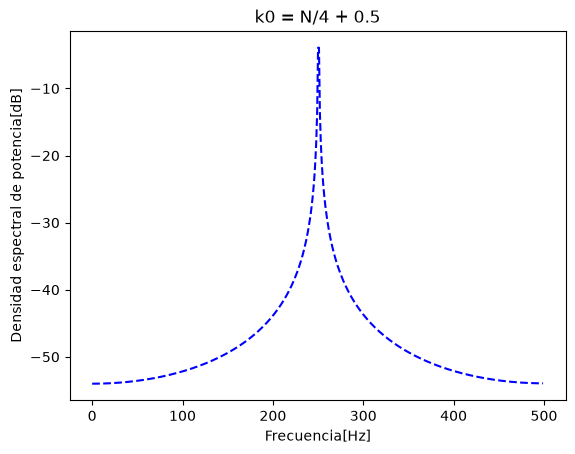

In [4]:
nn, xx2 = mi_funcion_sen( vmax, dc, f0[2], ph, N, fs)
XX2 = np.fft.fft(xx2) 
XX2_mod = np.abs(XX2[:N//2]) * 2/N
P2 = XX2_mod**2 / 2
P2_db = 10*np.log10(P2)
#grafico
plt.plot(ff_vec[:N//2], P2_db, 'b--')
plt.title("k0 = N/4 + 0.5")
plt.xlabel("Frecuencia[Hz]")
plt.ylabel("Densidad espectral de potencia[dB]")
plt.show()

Podemos ver como la potencia se reparte entre ambos bins vecinos y el valor máximo del espectro queda más alejado de 0 dB que en el caso anterior. 

#### Verificación de potencia mediante Parseval

Aunque la forma del espectro cambia entre los tres casos, la potencia total de la señal debería mantenerse. Para comprobarlo, se calcula la potencia tanto en el dominio del tiempo como en el dominio de la frecuencia utilizando la identidad de Parseval.

In [5]:
#k0= N/4
#potencia en el dominio del tiempo
P_t0 = np.mean(xx0**2)

#potencia en el dominio de la frecuencia
P_f0 = np.sum(np.abs(XX0)**2) / N**2

print("k0 = N/4")
print("Potencia en tiempo =", P_t0)
print("Potencia en frecuencia =", P_f0)

#k0= N/4 + 0,25
P_t1 = np.mean(xx1**2)
P_f1 = np.sum(np.abs(XX1)**2) / N**2
print("k0 = N/4 + 0.25")
print("Potencia en tiempo =", P_t1)
print("Potencia en frecuencia =", P_f1)

#k0= N/4 + 0,5
P_t2 = np.mean(xx2**2)
P_f2 = np.sum(np.abs(XX2)**2) / N**2
print("k0 = N/4 + 0.5")
print("Potencia en tiempo =", P_t2)
print("Potencia en frecuencia =", P_f2)

k0 = N/4
Potencia en tiempo = 1.0000000000000002
Potencia en frecuencia = 1.0000000000000002
k0 = N/4 + 0.25
Potencia en tiempo = 0.9989999999999998
Potencia en frecuencia = 0.9989999999999996
k0 = N/4 + 0.5
Potencia en tiempo = 1.0000000000000004
Potencia en frecuencia = 1.0000000000000007


Los resultados obtenidos verifican la identidad de Parseval, ya que en los tres casos la potencia calculada en el dominio del tiempo coincide prácticamente con la potencia obtenida en el dominio de la frecuencia.

Esto permite concluir que, aunque la forma del espectro cambia y aparece desparramo espectral cuando la frecuencia no coincide con un bin de la DFT, la potencia total de la señal no se pierde, sino que se redistribuye entre distintos bins.

#### Zero padding

A continuación se repite el análisis de las tres señales agregando $9N$ ceros al final de cada una. De esta forma, la longitud utilizada para calcular la FFT pasa de $N=1000$ a $N_zp=10000$ puntos.

El objetivo es obtener una grilla de frecuencias más densa y observar con mayor detalle la forma del espectro. El zero padding no agrega nueva información a la señal ni elimina el desparramo espectral.

##### Caso $k0= N/4$

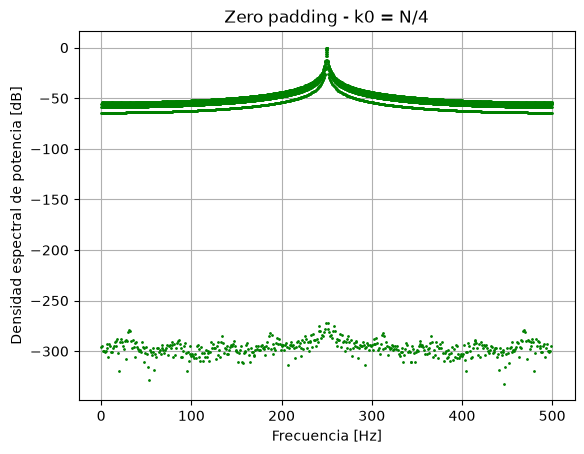

In [6]:
# agrego 9*N ceros al final de la señal original
xx0_zp = np.append(xx0, np.zeros(9*N))

# guardo la nueva longitud del vector
N_zp = len(xx0_zp)

# calculo FFT de la senal con ceros agregados 
XX0_zp = np.fft.fft(xx0_zp)

ff_vec_zp = np.fft.fftfreq(N_zp, 1/fs)

# modulo normalizado de la mitad positiva del espectro
XX0_zp_mod = np.abs(XX0_zp[:N_zp//2]) * 2/N

# calculo la potencia
P0_zp = XX0_zp_mod**2 / 2

# paso la potencia a dB
P0_db_zp = 10*np.log10(P0_zp)

# grafico
plt.figure()
plt.plot(ff_vec_zp[:N_zp//2], P0_db_zp, 'g.', markersize=2)
plt.title("Zero padding - k0 = N/4")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad espectral de potencia [dB]")
plt.grid()
plt.show()

Al aplicar zero padding se observa con mayor detalle la forma del espectro alrededor de la frecuencia de la senoidal. En el gráfico original solo se veía el pico en 250 Hz, mientras que al aumentar la cantidad de puntos de la FFT aparecen los valores intermedios entre los bins originales.

##### Caso $k0= N/4 + 0,25$ 

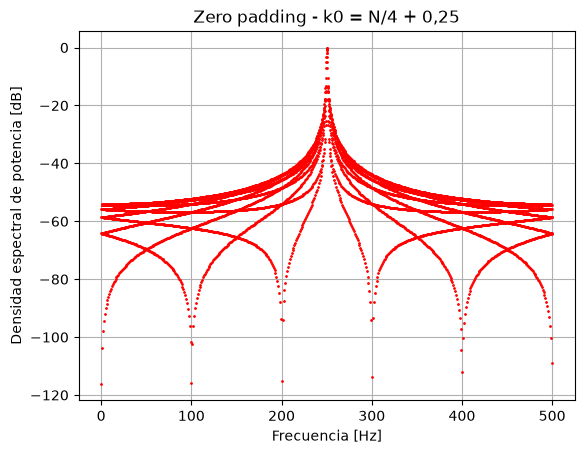

In [7]:
xx1_zp = np.append(xx1, np.zeros(9*N))
N_zp = len(xx1_zp)
XX1_zp = np.fft.fft(xx1_zp)
ff_vec_zp = np.fft.fftfreq(N_zp, 1/fs)
XX1_zp_mod = np.abs(XX1_zp[:N_zp//2]) * 2/N
P1_zp = XX1_zp_mod**2 / 2
P1_db_zp = 10*np.log10(P1_zp)

# grafico
plt.figure()
plt.plot(ff_vec_zp[:N_zp//2], P1_db_zp, 'r.', markersize=2)
plt.title("Zero padding - k0 = N/4 + 0,25")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad espectral de potencia [dB]")
plt.grid()
plt.show()

En este caso el desparramo espectral sigue presente, ya que la frecuencia de la senoidal no coincide exactamente con un bin de la DFT.

Sin embargo, al aplicar zero padding se puede observar con mayor detalle la forma del espectro y la zona donde se encuentra su máximo. Por lo tanto, el zero padding mejora la visualización del espectro, pero no elimina el desparramo.

##### Caso $k0= N/4 + 0,5$

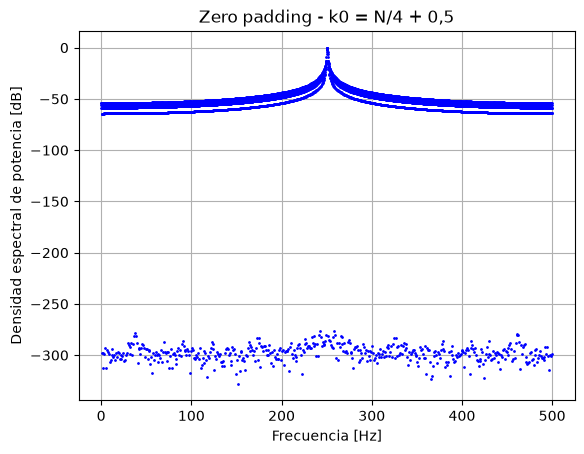

In [8]:
xx2_zp = np.append(xx2, np.zeros(9*N))
N_zp = len(xx2_zp)
XX2_zp = np.fft.fft(xx2_zp)
ff_vec_zp = np.fft.fftfreq(N_zp, 1/fs)
XX2_zp_mod = np.abs(XX2_zp[:N_zp//2]) * 2/N
P2_zp = XX2_zp_mod**2 / 2
P2_db_zp = 10*np.log10(P2_zp)

# grafico
plt.figure()
plt.plot(ff_vec_zp[:N_zp//2], P2_db_zp, 'b.', markersize=2)
plt.title("Zero padding - k0 = N/4 + 0,5")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad espectral de potencia [dB]")
plt.grid()
plt.show()

En este último caso, la separación entre bins es de 0,1 Hz, la frecuencia de la señal, 250,5 Hz, eso coincide con uno de los nuevos puntos de la FFT.

Por este motivo, el máximo del espectro puede visualizarse mucho más cerca de 0 dB y pudimos representar con mayor detalle el mismo espectro.

#### Conclusión

En este trabajo práctico pudimos ver cómo pequeñas variaciones en la frecuencia de una senoidal pueden cambiar mucho la forma en que se observa su espectro, apareciendo el desparramo espectral cuando la frecuencia no coincide con los bins de la DFT.

También comprobar con Parseval que la potencia total de la señal se mantiene, aunque se distribuya entre distintos bins. Por último, con el zero padding notamos que no se agrega nueva información, sino que se obtiene una grilla de frecuencias más densa que permite visualizar y ubicar mejor los máximos del espectro.